In [73]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os



In [74]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import IPython.display as ipd
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import tensorflow
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras 
import keras_tuner

from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [75]:
sample = '/kaggle/input/urbansound8k/fold7/101848-9-0-9.wav'
urbansoundData = pd.read_csv('/kaggle/input/urbansound8k/UrbanSound8K.csv')
audio_dataset_path = '/kaggle/input/urbansound8k'

In [76]:
plt.figure(figsize=(10,10 ))
ipd.Audio(sample)

<Figure size 1000x1000 with 0 Axes>

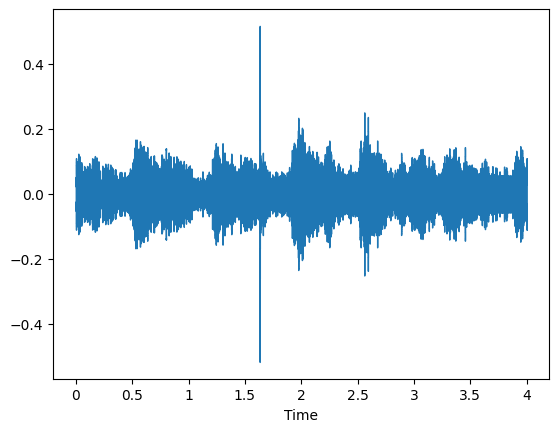

In [77]:
#Sample rate is the number of samples per second that are taken of a waveform to create a discete digital signal.
data,sample_rate = librosa.load(sample)
librosa.display.waveshow(data,sr = sample_rate)

In [78]:
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(sample)

In [79]:
urbansoundData.sample()

,slice_file_name,fsID,start,end,salience,fold,classID,class
1252,130961-4-3-1.wav,130961,253.731956,257.731956,1,7,4,drilling


In [80]:
urbansoundData.shape

(8732, 8)

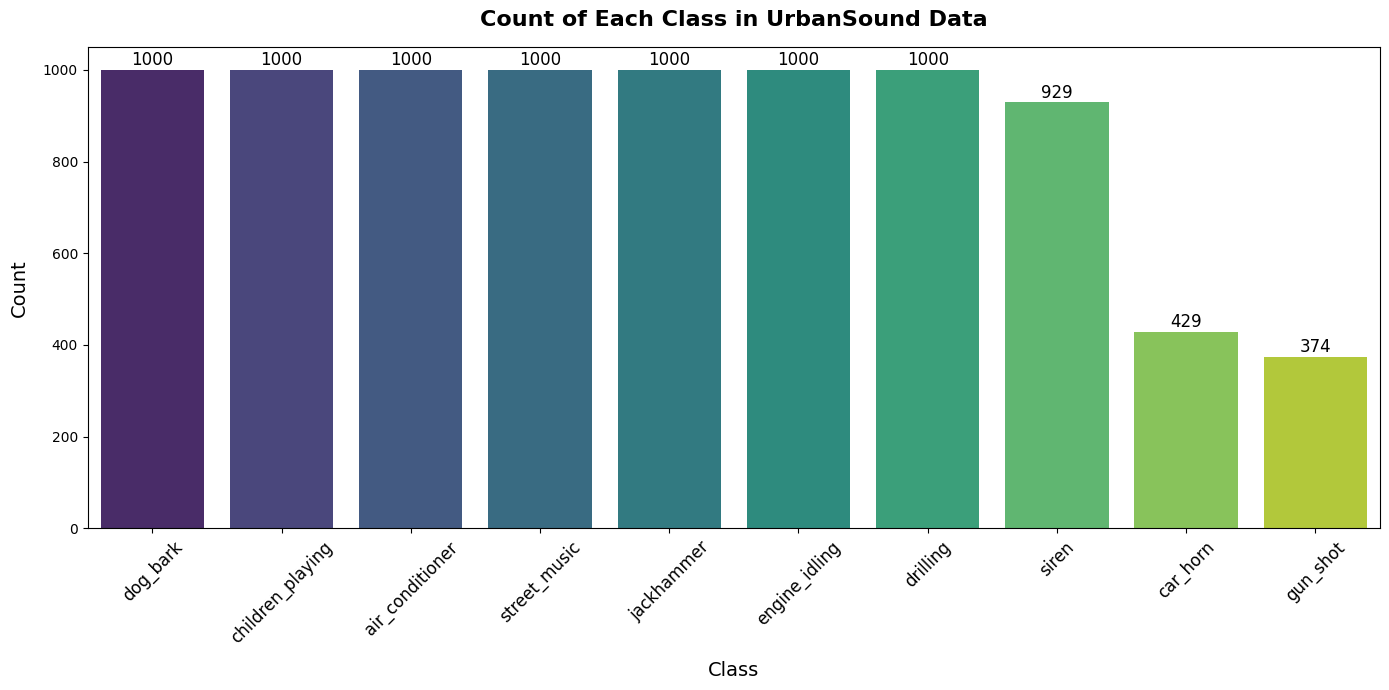

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `urbansoundData` is your DataFrame and it contains a 'class' column
class_counts = urbansoundData['class'].value_counts()

# Visualization using Seaborn
plt.figure(figsize=(14, 7))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

# Add title and labels
plt.title("Count of Each Class in UrbanSound Data", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Class", fontsize=14, labelpad=10)
plt.ylabel("Count", fontsize=14, labelpad=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, fontsize=12)

# Annotate each bar with the count value
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


In [82]:
dat1, sampling_rate1 = librosa.load('../input/urbansound8k/fold5/100032-3-0-0.wav')
dat2, sampling_rate2 = librosa.load('../input/urbansound8k/fold5/100263-2-0-117.wav')

Text(0.5, 1.0, 'Linear-frequency power spectrogram')

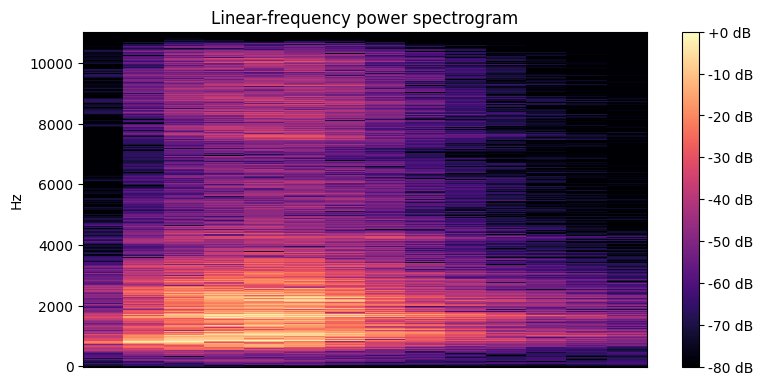

In [83]:
plt.figure(figsize=(20, 20))
D = librosa.amplitude_to_db(np.abs(librosa.stft(dat1)), ref=np.max)
plt.subplot(4, 2, 1)
librosa.display.specshow(D, y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Linear-frequency power spectrogram')

Text(0.5, 1.0, 'Linear-frequency power spectrogram')

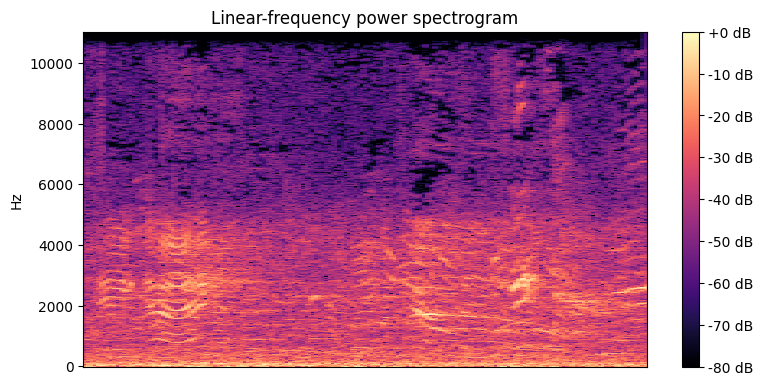

In [84]:
plt.figure(figsize=(20, 20))
D = librosa.amplitude_to_db(np.abs(librosa.stft(dat2)), ref=np.max)
plt.subplot(4, 2, 1)
librosa.display.specshow(D, y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Linear-frequency power spectrogram')

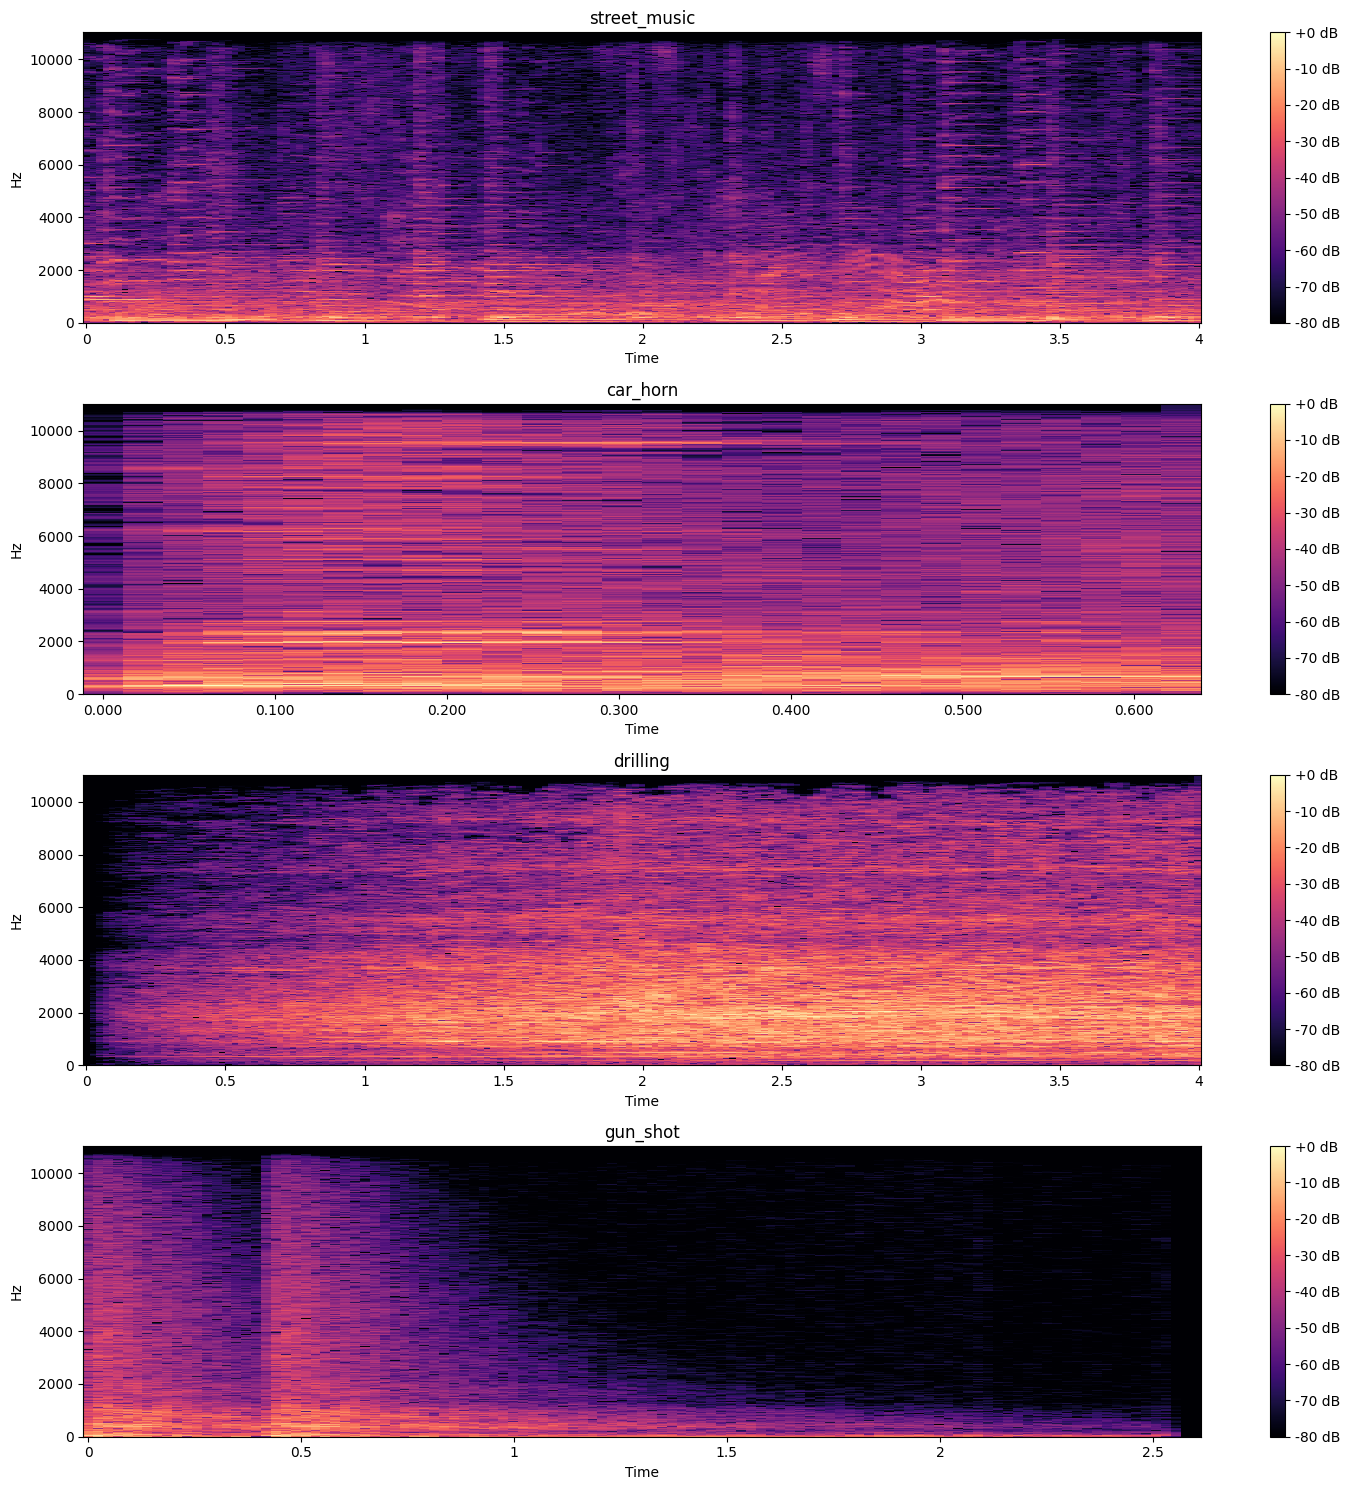

In [85]:
# Assuming `urbansoundData` DataFrame is already loaded
arr = np.array(urbansoundData["slice_file_name"])
fold = np.array(urbansoundData["fold"])
cla = np.array(urbansoundData["class"])

# Classes to display
selected_classes = ["street_music", "car_horn", "drilling", "gun_shot"]

# Filter indices for the selected classes
filtered_indices = [np.where(cla == class_name)[0][0] for class_name in selected_classes]

plt.figure(figsize=(15, 15))

# Loop through the filtered indices and plot
for idx, i in enumerate(filtered_indices):
    # Construct the file path
    path = '../input/urbansound8k/fold' + str(fold[i]) + '/' + arr[i]
    data, sampling_rate = librosa.load(path)

    # Plot the spectrogram
    plt.subplot(len(selected_classes), 1, idx + 1)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
    librosa.display.specshow(D, y_axis='linear', x_axis='time', sr=sampling_rate)
    plt.colorbar(format='%+2.0f dB')
    plt.title(cla[i])
    plt.tight_layout()

# Display the plots
plt.show()

In [86]:
#lets apply on any single random wav file first for our understanding
mfccs = librosa.feature.mfcc(y=data, sr = sample_rate, n_mfcc=40)
print(mfccs.shape)
print(mfccs)

(40, 113)
[[-1.4507486e+02 -9.0331123e+01 -9.3731026e+01 ... -6.1920050e+02
  -6.6171613e+02 -6.6171613e+02]
 [ 8.9394806e+01  9.5265900e+01  9.7520790e+01 ...  5.4042000e+01
   0.0000000e+00  0.0000000e+00]
 [ 1.6533920e+01  1.1827032e+01  5.7046289e+00 ...  4.0316391e+01
   0.0000000e+00  0.0000000e+00]
 ...
 [ 3.5413525e-01  3.6169202e+00  1.7003672e+00 ... -3.0576366e-01
   0.0000000e+00  0.0000000e+00]
 [ 2.2086112e+00  1.8255885e+00 -1.1635063e+00 ... -2.8394783e-01
   0.0000000e+00  0.0000000e+00]
 [ 7.4487786e+00  4.7130356e+00  4.3884587e-01 ... -5.4333425e-01
   0.0000000e+00  0.0000000e+00]]


In [87]:
def feature_extraction(file):
    audio, sample_rate = librosa.load(file)
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=64)
    mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)
    return mfccs_scaled_features

In [88]:
from glob import glob# Iterating through each row
# Extract features for speech files
extracted_features = []
c = 0
for file in glob('/kaggle/input/ljspeech-sr16k-dataset/wavs/*.wav'):
    data = feature_extraction(file)
    extracted_features.append([data, 'speech'])
    c += 1
    if c > 1000:  # Limit to 1000 samples for speech
        break

# Extract features for UrbanSound8K dataset
audio_dataset_path = "/kaggle/input/urbansound8k"
for index_num, row in tqdm(urbansoundData.iterrows()):
    if row['class'] in {'street_music', 'car_horn', 'drilling'}:
        audioFile = os.path.join(audio_dataset_path, 'fold' + str(row['fold']), row['slice_file_name'])
        final_class_labels = row["class"]
        data = feature_extraction(audioFile)
        extracted_features.append([data, final_class_labels])

8732it [01:09, 124.84it/s]


In [89]:
# Convert to DataFrame
extracted_features_Dataframe = pd.DataFrame(extracted_features, columns=['features', 'class'])

extracted_features_Dataframe.sample(20)

,features,class
1887,"[-265.975, 102.80261, -17.847145, 14.064007, 0...",car_horn
2978,"[-260.75818, 151.97572, -125.348785, 25.576632...",car_horn
2190,"[-307.70657, 140.87991, -30.150137, 23.101105,...",street_music
2012,"[-192.04951, 86.646255, -16.121382, 10.424817,...",drilling
961,"[-325.37518, 119.40404, -26.968834, 43.617573,...",speech
254,"[-328.69513, 106.01142, -27.625309, 27.61913, ...",speech
2939,"[-172.24655, 126.04435, -49.87301, 36.366047, ...",car_horn
775,"[-325.33124, 96.88022, -15.74991, 38.86273, -3...",speech
1741,"[-193.62875, 40.278103, -23.665161, 5.7402554,...",drilling
3275,"[-187.289, 130.62988, -23.76374, -6.125744, -1...",street_music


In [90]:
print(extracted_features_Dataframe['class'].value_counts())

class
speech          1001
street_music    1000
drilling        1000
car_horn         429
Name: count, dtype: int64


In [91]:

extracted_features_Dataframe.loc[extracted_features_Dataframe['class'].isin(['car_horn', 'drilling']), 'class'] = 'noise'
noise_indices = extracted_features_Dataframe[extracted_features_Dataframe['class'] == 'noise'].index


In [92]:

X = np.array(extracted_features_Dataframe['features'].tolist())
y = np.array(extracted_features_Dataframe['class'].tolist())

In [93]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
y=to_categorical(labelencoder.fit_transform(y))
y

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [94]:
label_mapping = dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_)))
print("Label Mapping:")
print(label_mapping)

Label Mapping:
{'noise': 0, 'speech': 1, 'street_music': 2}


In [95]:
X.shape,y.shape

((3430, 64), (3430, 3))

In [162]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.40, random_state=42)

In [163]:
X_train.shape,y_train.shape

((2058, 64), (2058, 3))

In [164]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Activation , Dropout
num_labels = y.shape[1]
model = Sequential()

model.add(Dense(64, input_shape=(64,)))
model.add(Activation('relu'))
model.add(Dropout(0.5))


model.add(Dense(64))

model.add(Dense(num_labels))
model.add(Activation('softmax'))
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_47 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 3)                   │             195 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_48 (Activation)           │ (None, 3)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,515 (33.26 KB)

 Trainable params: 8,515 (33.26 KB)

 Non-trainable params: 0 (0.00 B)

In [165]:
import tensorflow as tf
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [166]:
history=model.fit(
          X_train, 
          y_train, 
          batch_size=32, 
          epochs=100,
          validation_data=(X_test, y_test),
         )

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.4042 - loss: 19.4664 - val_accuracy: 0.8069 - val_loss: 0.8854
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7246 - loss: 1.9399 - val_accuracy: 0.8462 - val_loss: 0.4655
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 0.6836 - val_accuracy: 0.8243 - val_loss: 0.4265
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7508 - loss: 0.8759 - val_accuracy: 0.8571 - val_loss: 0.3155
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8134 - loss: 0.4492 - val_accuracy: 0.8710 - val_loss: 0.2924
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7922 - loss: 0.4797 - val_accuracy: 0.8200 - val_loss: 0.5248
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7906 - loss: 0.5599 - val_accuracy: 0.8418 - val_loss: 0.4243
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8062 - loss: 0.4639 - val_accuracy: 0.8666 -

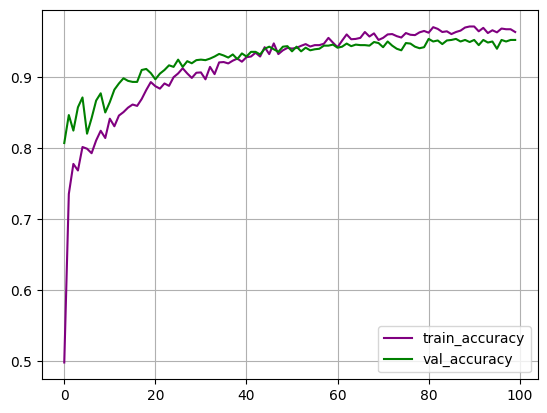

In [167]:
plt.plot(history.history['accuracy'], color = 'purple',label = 'train_accuracy' )
plt.plot(history.history['val_accuracy'], color = 'green', label = 'val_accuracy')
plt.legend()
plt.grid()
plt.plot()
plt.show()

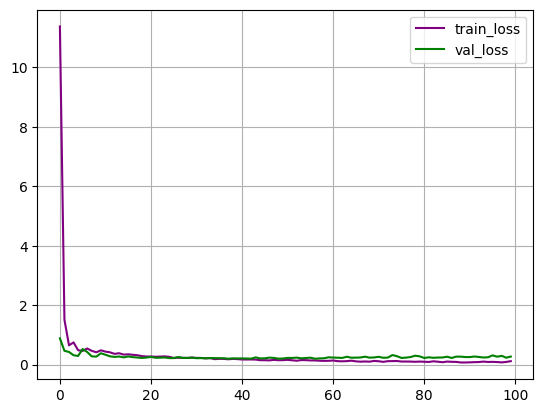

In [168]:
plt.plot(history.history['loss'], color = 'purple', label = 'train_loss')
plt.plot(history.history['val_loss'], color = 'green', label = 'val_loss')
plt.legend()
plt.grid()
plt.plot()
plt.show()

In [169]:
predict_x=model.predict(X_test) 
classes_x=np.argmax(predict_x,axis=1)
print(classes_x)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[1 2 1 ... 2 0 0]


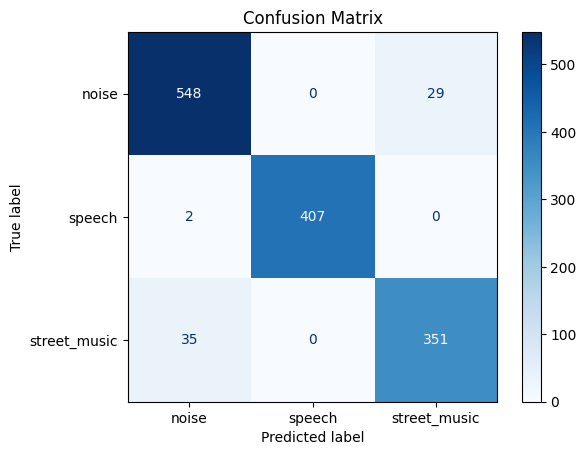

In [170]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Convert y_test from one-hot encoding to single-label format, if necessary
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, classes_x)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['noise', 'speech', 'street_music'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [171]:
!pip install resampy


In [172]:
!pip install resampy librosa


In [173]:
import resampy
print("resampy successfully installed and imported!")

# Load the audio file
#filename = "/kaggle/input/mytestdata/Recording.m4a"
filename = "/kaggle/input/speaker-recognition-audio-dataset/50_speakers_audio_data/Speaker0028/Speaker28_002.wav"
#preprocess the audio file
audio, sample_rate = librosa.load(filename) 
mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=64)
mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)

#Reshape MFCC feature to 2-D array
mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)

#predicted_label=model.predict_classes(mfccs_scaled_features)
x_predict=model.predict(mfccs_scaled_features) 
predicted_label=np.argmax(x_predict,axis=1)
print(predicted_label)
prediction_class = labelencoder.inverse_transform(predicted_label) 
print(prediction_class)
print(x_predict)

resampy successfully installed and imported!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
[0]
['noise']
[[1.0000000e+00 3.8452950e-17 1.7182167e-14]]
